In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# Continuous Dynamical System
# -------------------------------
class LiquidSystem(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.W = nn.Parameter(torch.randn(dim, dim) * 0.05)

    def forward(self, x, u, dt=0.1):
        dx = -0.5 * x + torch.tanh(x @ self.W + u)
        return x + dt * dx

In [11]:
def generate_input(seq_len, dim, mode="sine"):
    t = torch.linspace(0, 10, seq_len).to(device)
    
    if mode == "sine":
        return torch.sin(t).unsqueeze(1).repeat(1, dim)
    
    elif mode == "constant":
        return torch.ones(seq_len, dim).to(device) * 0.5
    
    elif mode == "noise":
        return torch.randn(seq_len, dim).to(device) * 0.2
    
    elif mode == "impulse":
        u = torch.zeros(seq_len, dim).to(device)
        u[10:20] = 1.0
        return u
    
    else:
        return torch.zeros(seq_len, dim).to(device)

In [12]:
model = LiquidSystem().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 300
seq_len = 200
dim = 64

print("Training started...")

for epoch in range(epochs):
    optimizer.zero_grad()
    
    x = torch.zeros(1, dim).to(device)
    u = generate_input(seq_len, dim, mode="sine")
    
    prediction_loss = 0
    energy_loss = 0
    
    for t in range(seq_len - 2):
        x_next = model(x, u[t])
        x_future = model(x_next, u[t+1])   # 🔥 KEY FIX
        
        # Temporal consistency
        prediction_loss += torch.mean((x_future - x_next.detach())**2)
        
        # Local energy penalty
        energy_loss += torch.mean(torch.abs(x))
        
        x = x_next
    
    loss = prediction_loss + 0.01 * energy_loss
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Training started...
Epoch 0 | Loss: 1.8791
Epoch 50 | Loss: 2.7977
Epoch 100 | Loss: 2.8703
Epoch 150 | Loss: 2.8872
Epoch 200 | Loss: 2.8160
Epoch 250 | Loss: 2.7639


In [15]:
def collect_trajectory(mode):
    x = torch.zeros(1, dim).to(device)
    u = generate_input(seq_len, dim, mode=mode)
    
    states = []
    
    with torch.no_grad():
        for t in range(seq_len):
            x = model(x, u[t])
            states.append(x.cpu().numpy())
    
    return np.array(states).squeeze()

In [16]:
traj_sine = collect_trajectory("sine")
traj_const = collect_trajectory("constant")
traj_noise = collect_trajectory("noise")
traj_impulse = collect_trajectory("impulse")

all_states = np.vstack([traj_sine, traj_const, traj_noise, traj_impulse])

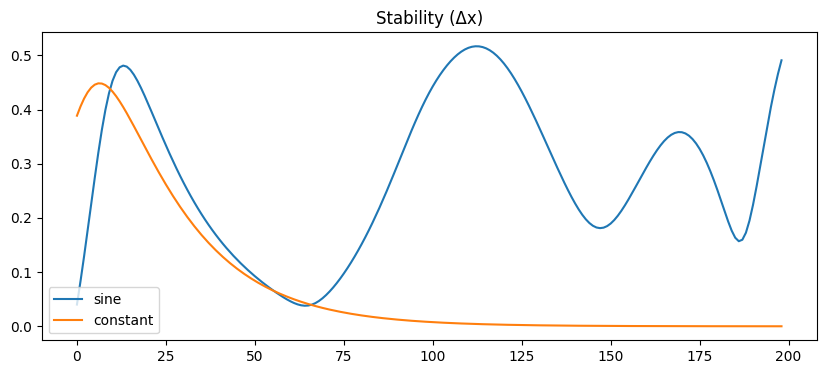

In [17]:
def compute_delta(traj):
    return np.linalg.norm(traj[1:] - traj[:-1], axis=1)

delta_sine = compute_delta(traj_sine)
delta_const = compute_delta(traj_const)

plt.figure(figsize=(10,4))
plt.plot(delta_sine, label="sine")
plt.plot(delta_const, label="constant")
plt.title("Stability (Δx)")
plt.legend()
plt.show()

In [18]:
kmeans = KMeans(n_clusters=5, random_state=0).fit(all_states)
labels = kmeans.labels_

print("Dhātu candidates:", len(np.unique(labels)))

Dhātu candidates: 5


In [19]:
def sandhi_input():
    t = torch.linspace(0, 10, seq_len).to(device)
    sine = torch.sin(t)
    cos = torch.cos(t)
    return ((sine + cos)/2).unsqueeze(1).repeat(1, dim)

def probe(u):
    x = torch.zeros(1, dim).to(device)
    states = []
    
    with torch.no_grad():
        for t in range(seq_len):
            x = model(x, u[t])
            states.append(x.cpu().numpy())
    
    return np.array(states).squeeze()

res_sine = probe(generate_input(seq_len, dim, "sine"))
res_cos  = probe(generate_input(seq_len, dim, "constant"))
res_sandhi = probe(sandhi_input())

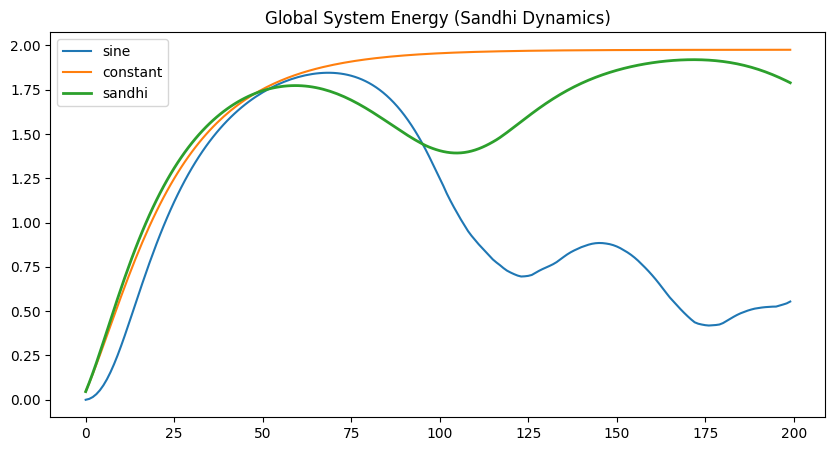

In [20]:
def energy(traj):
    return np.mean(np.abs(traj), axis=1)

plt.figure(figsize=(10,5))
plt.plot(energy(res_sine), label="sine")
plt.plot(energy(res_cos), label="constant")
plt.plot(energy(res_sandhi), label="sandhi", linewidth=2)
plt.legend()
plt.title("Global System Energy (Sandhi Dynamics)")
plt.show()